# Combo B: Single-Node Action + 2-Layer GCN + Curriculum Learning + Potential-Based Reward Shaping**Goal**: Optimize graph layouts using reinforcement learning with:- **Single-node actions**: Select the node with highest per-node crossings, move only that node by [dx, dy]- **2-layer GCN feature extractor**: Lightweight graph neural network (no attention)- **Curriculum learning**: Phase 1 on small graphs (≤30 nodes), Phase 2 on all graphs- **Potential-based reward shaping**: Φ(s) = -crossings / max(initial_crossings, 1), shaped_reward = γΦ(s') - Φ(s)

## 0. Setup & Configuration

In [9]:
import os
import sys
import time
import json
import random
import glob
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import networkx as nx
import matplotlib.pyplot as plt
from typing import Dict, List, Tuple, Optional, Type

import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

PyTorch version: 2.7.0
Device: cpu


In [10]:
# ============================================================
# CONFIGURATION — Combo B: Single-Node + 2-Layer GCN + Curriculum
# ============================================================
ROME_DIR = "/Users/mao/Downloads/Project_RL/rome"  # <-- your rome dataset path
SAVE_PATH = "ppo_combo_b"
OUTPUT_DIR = "./results_combo_b"

MAX_NODES = 100
MAX_EDGES = 200
TIMESTEPS_PHASE1 = 100000   # curriculum phase 1: small graphs
TIMESTEPS_PHASE2 = 200000   # curriculum phase 2: all graphs
N_STARTS = 10               # multi-start count for evaluation

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Rome dir: {ROME_DIR}")
print(f"Graphs found: {len([f for f in os.listdir(ROME_DIR) if f.endswith('.graphml')])}")


Rome dir: /Users/mao/Downloads/Project_RL/rome
Graphs found: 11534


## 1. XingLoss — Edge Crossing Computation

In [11]:
class XingLoss:
    def __init__(self, G: nx.Graph, device=None, soft=False, sharpness=10.0):
        nodes = list(G.nodes())
        edges = [[nodes.index(i), nodes.index(j)] for i, j in G.edges]
        self.edges = torch.tensor(edges, dtype=torch.long)
        if device is None:
            device = torch.device("cpu")
        self.device = device
        self.soft = soft
        self.sharpness = sharpness

    @staticmethod
    def cross_2d(v, u):
        return v[..., 0] * u[..., 1] - v[..., 1] * u[..., 0]

    @staticmethod
    def dot_2d(v, u):
        return torch.sum(v * u, dim=-1)

    def edges_intersect(self, edge_1_start_pos, edge_1_end_pos,
                        edge_2_start_pos, edge_2_end_pos, eps=1e-6):
        p = edge_1_start_pos
        q = edge_2_start_pos
        r = edge_1_end_pos - p
        s = edge_2_end_pos - q
        p = p + eps * r
        q = q + eps * s
        r = r * (1 - 2 * eps)
        s = s * (1 - 2 * eps)
        qmp = q - p
        qmpxs = XingLoss.cross_2d(qmp, s)
        qmpxr = XingLoss.cross_2d(qmp, r)
        rxs = XingLoss.cross_2d(r, s)
        rdr = XingLoss.dot_2d(r, r)
        t0 = XingLoss.dot_2d(qmp, r) / (rdr + 1e-12)
        t1 = t0 + XingLoss.dot_2d(s, r) / (rdr + 1e-12)
        t = qmpxs / (rxs + 1e-12)
        u = qmpxr / (rxs + 1e-12)

        def sigmoid(x):
            return torch.sigmoid(x * self.sharpness)

        if self.soft:
            p5 = torch.tensor(0.5, device=rxs.device, dtype=rxs.dtype)
            M_peak = sigmoid(p5) * (1 - sigmoid(-p5))
            def inside_norm(t):
                M = sigmoid(t) * (1 - sigmoid(t - 1))
                return M / (M_peak + 1e-12)
            Mt = inside_norm(t)
            Mu = inside_norm(u)
            return Mt * Mu
        else:
            zero = torch.tensor(0.0, device=rxs.device, dtype=rxs.dtype)
            parallel = torch.isclose(rxs, zero)
            collinear = parallel & torch.isclose(qmpxr, zero)
            intersects_collinear = collinear & ((torch.max(t0, t1) > 0) & (torch.min(t0, t1) < 1))
            intersects_skew = ~parallel & (t > 0) & (t < 1) & (u > 0) & (u < 1)
            return intersects_collinear | intersects_skew

    def __call__(self, coords: torch.Tensor) -> torch.Tensor:
        num_edges = self.edges.shape[0]
        idx_i, idx_j = torch.triu_indices(num_edges, num_edges, offset=1)
        edge_i = self.edges[idx_i]
        edge_j = self.edges[idx_j]
        no_shared_nodes = ~(
            (edge_i[:, 0] == edge_j[:, 0]) | (edge_i[:, 0] == edge_j[:, 1]) |
            (edge_i[:, 1] == edge_j[:, 0]) | (edge_i[:, 1] == edge_j[:, 1])
        )
        edge_i = edge_i[no_shared_nodes]
        edge_j = edge_j[no_shared_nodes]
        if edge_i.shape[0] == 0:
            return torch.tensor(0.0, device=coords.device)
        edge_1_start_pos = coords[edge_i[:, 0], :2]
        edge_1_end_pos = coords[edge_i[:, 1], :2]
        edge_2_start_pos = coords[edge_j[:, 0], :2]
        edge_2_end_pos = coords[edge_j[:, 1], :2]
        crossings = self.edges_intersect(edge_1_start_pos, edge_1_end_pos,
                                         edge_2_start_pos, edge_2_end_pos)
        return crossings.sum().float()

print("XingLoss defined.")

XingLoss defined.


## 2. GNN Layers — Pure PyTorch (no torch_geometric needed)Custom GCN and multi-head GAT layers.

In [14]:
class GCNLayer(nn.Module):
    """Graph Convolutional Layer: H' = D^{-1/2} A D^{-1/2} H W + b"""
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.W = nn.Linear(in_dim, out_dim, bias=False)
        self.bias = nn.Parameter(torch.zeros(out_dim))

    def forward(self, x, adj_norm):
        return adj_norm @ self.W(x) + self.bias


class GATLayer(nn.Module):
    """Graph Attention Layer (single-head)."""
    def __init__(self, in_dim, out_dim, dropout=0.1):
        super().__init__()
        self.W = nn.Linear(in_dim, out_dim, bias=False)
        self.attn_src = nn.Linear(out_dim, 1, bias=False)
        self.attn_dst = nn.Linear(out_dim, 1, bias=False)
        self.leaky_relu = nn.LeakyReLU(0.2)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, adj):
        h = self.W(x)
        attn_src = self.attn_src(h)
        attn_dst = self.attn_dst(h)
        attn = attn_src + attn_dst.T
        attn = attn.masked_fill(adj == 0, float('-inf'))
        attn = self.leaky_relu(attn)
        attn = F.softmax(attn, dim=-1)
        attn = torch.nan_to_num(attn, nan=0.0)
        attn = self.dropout(attn)
        return attn @ h


class MultiHeadGATLayer(nn.Module):
    """Multi-head GAT: concat K heads then project."""
    def __init__(self, in_dim, out_dim, num_heads=4, dropout=0.1):
        super().__init__()
        assert out_dim % num_heads == 0
        head_dim = out_dim // num_heads
        self.heads = nn.ModuleList([
            GATLayer(in_dim, head_dim, dropout) for _ in range(num_heads)
        ])
        self.proj = nn.Linear(out_dim, out_dim)

    def forward(self, x, adj):
        head_outputs = [head(x, adj) for head in self.heads]
        h = torch.cat(head_outputs, dim=-1)
        return self.proj(h)


class GNNEncoder(nn.Module):
    """3-layer GNN encoder with residual connections."""
    def __init__(self, in_dim=10, hidden_dim=64, num_layers=3, use_attention=True, dropout=0.1):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.input_proj = nn.Sequential(
            nn.Linear(in_dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.ReLU(),
        )
        self.gnn_layers = nn.ModuleList()
        self.layer_norms = nn.ModuleList()
        for _ in range(num_layers):
            if use_attention:
                self.gnn_layers.append(MultiHeadGATLayer(hidden_dim, hidden_dim, num_heads=4, dropout=dropout))
            else:
                self.gnn_layers.append(GCNLayer(hidden_dim, hidden_dim))
            self.layer_norms.append(nn.LayerNorm(hidden_dim))

    def forward(self, x, adj):
        h = self.input_proj(x)
        for gnn, ln in zip(self.gnn_layers, self.layer_norms):
            h_new = gnn(h, adj)
            h_new = ln(h_new)
            h_new = F.relu(h_new)
            h = h + h_new  # residual
        return h

# Quick test
enc = GNNEncoder(in_dim=10, hidden_dim=64)
x_test = torch.randn(20, 10)
adj_test = torch.eye(20)
out_test = enc(x_test, adj_test)
print(f"GNN Encoder: {sum(p.numel() for p in enc.parameters()):,} params")
print(f"Input: {x_test.shape} → Output: {out_test.shape}")

GNN Encoder: 26,368 params
Input: torch.Size([20, 10]) → Output: torch.Size([20, 64])


## 3. Feature Extractor (2-Layer GCN)SB3-compatible feature extractor using 2-layer GCN (lightweight for curriculum learning).

In [12]:
class GNNFeatureExtractorSingleNode(BaseFeaturesExtractor):
    """2-layer GCN feature extractor for Combo B (single-node actions)."""

    def __init__(self, observation_space, max_nodes, max_edges, node_feat_dim=10,
                 global_feat_dim=5, hidden_dim=32, num_gnn_layers=2,
                 use_attention=False):
        super().__init__(observation_space, features_dim=hidden_dim)
        self.max_nodes = max_nodes
        self.max_edges = max_edges
        self.node_feat_dim = node_feat_dim
        self.global_feat_dim = global_feat_dim
        self.hidden_dim = hidden_dim

        # Input projection
        self.node_proj = nn.Linear(node_feat_dim, hidden_dim)
        self.global_proj = nn.Linear(global_feat_dim, hidden_dim)

        # GNN layers (2-layer)
        self.gnn_layers = nn.ModuleList()
        self.layer_norms = nn.ModuleList()
        for _ in range(num_gnn_layers):
            if use_attention:
                self.gnn_layers.append(MultiHeadGATLayer(hidden_dim, hidden_dim,
                                                         num_heads=4, dropout=0.1))
            else:
                self.gnn_layers.append(GCNLayer(hidden_dim, hidden_dim))
            self.layer_norms.append(nn.LayerNorm(hidden_dim))

        # Aggregation
        self.agg = nn.Linear(hidden_dim * 2, hidden_dim)

    def forward(self, observations):
        # Unpack observation dict
        node_feats = observations["node_features"]  # (batch, max_nodes, 10)
        global_feats = observations["global_features"]  # (batch, 5)
        adj_matrix = observations["adjacency_matrix"]  # (batch, max_nodes, max_nodes)

        batch_size = node_feats.shape[0]
        device = node_feats.device

        # Project inputs
        node_h = self.node_proj(node_feats)  # (batch, max_nodes, hidden_dim)
        global_h = self.global_proj(global_feats)  # (batch, hidden_dim)

        # Apply GNN layers
        for gnn, ln in zip(self.gnn_layers, self.layer_norms):
            if isinstance(gnn, GCNLayer):
                # Normalize adjacency: add self-loops and normalize
                adj_with_loops = adj_matrix + torch.eye(self.max_nodes,
                                                        device=device).unsqueeze(0)
                degree = adj_with_loops.sum(dim=-1, keepdim=True).clamp(min=1e-8)
                adj_norm = adj_with_loops / degree
                node_h_new = torch.stack([gnn(node_h[i], adj_norm[i])
                                           for i in range(batch_size)])
            else:
                # GAT layer
                node_h_new = torch.stack([gnn(node_h[i], adj_matrix[i])
                                           for i in range(batch_size)])

            node_h_new = ln(node_h_new)
            node_h_new = F.relu(node_h_new)
            node_h = node_h + node_h_new  # residual

        # Global aggregation: mean of node features
        node_agg = node_h.mean(dim=1)  # (batch, hidden_dim)

        # Combine with global features
        combined = torch.cat([node_agg, global_h], dim=-1)  # (batch, hidden_dim * 2)
        output = self.agg(combined)  # (batch, hidden_dim)

        return output

print("GNNFeatureExtractorSingleNode defined (2-layer GCN).")


GNNFeatureExtractorSingleNode defined (2-layer GCN).


## 4. Environment — Single-Node Action + Potential-Based Reward ShapingEnvironment that selects the highest-crossing node and moves it, with potential-based shaped rewards.

### GD² Pre-optimization
Before PPO starts, we run 150 steps of gradient descent on soft crossing loss to optimize the neato layout. This gives PPO a much better starting point (similar to building on SmartGD/DeepGD results).

In [13]:
class GraphLayoutEnvSingleNode(gym.Env):
    """Single-node action environment for graph layout optimization.
    
    Action: [dx, dy] for the node with highest per-node crossings.
    Reward: base crossing reduction + potential-based shaping.
    """
    metadata = {'render_modes': []}

    def __init__(self, graph_paths, max_steps=200, max_nodes=MAX_NODES, max_edges=MAX_EDGES):
        super().__init__()
        self.graph_paths = graph_paths
        self.max_steps = max_steps
        self.max_nodes = max_nodes
        self.max_edges = max_edges

        # Action: [dx, dy] for single node
        self.action_space = spaces.Box(low=-1, high=1, shape=(2,), dtype=np.float32)

        # Observation: node features + global features + adjacency
        self.observation_space = spaces.Dict({
            "node_features": spaces.Box(low=-np.inf, high=np.inf, shape=(max_nodes, 10), dtype=np.float32),
            "global_features": spaces.Box(low=-np.inf, high=np.inf, shape=(5,), dtype=np.float32),
            "adjacency_matrix": spaces.Box(low=0, high=1, shape=(max_nodes, max_nodes), dtype=np.float32),
        })

        self.G = None
        self.coords = None
        self.step_count = 0
        self.initial_crossings = None
        self.current_crossings = None
        self.best_crossings = None
        self.best_coords = None
        self.patience = 0
        self.adaptive_scale = 1.0
        self.xing_loss = None


    def _load_graph(self, path):
        G = nx.read_graphml(path)
        G = nx.convert_node_labels_to_integers(G, ordering="sorted")
        if not nx.is_connected(G):
            G = G.subgraph(max(nx.connected_components(G), key=len)).copy()
            G = nx.convert_node_labels_to_integers(G, ordering="sorted")
        return G

    def _get_neato_layout(self, G):
        try:
            pos = nx.nx_agraph.graphviz_layout(G, prog="neato")
        except Exception:
            pos = nx.spring_layout(G, seed=42)
            pos = {k: (v[0]*100, v[1]*100) for k, v in pos.items()}
        return np.array([[pos[v][0], pos[v][1]] for v in G.nodes()], dtype=np.float32)

    def _compute_topo_features(self, G):
        """7 static topology features per node."""
        n = G.number_of_nodes()
        nodes = list(range(n))
        degrees = np.array([G.degree(v) for v in nodes], dtype=np.float32)
        max_deg = degrees.max()
        norm_deg = degrees / max_deg if max_deg > 0 else degrees

        cc = nx.clustering(G)
        clust = np.array([cc.get(v, 0.0) for v in nodes], dtype=np.float32)

        bc = nx.betweenness_centrality(G)
        between = np.array([bc.get(v, 0.0) for v in nodes], dtype=np.float32)

        try: pr = nx.pagerank(G, max_iter=100)
        except: pr = {v: 1.0/n for v in nodes}
        pagerank = np.array([pr.get(v, 0.0) for v in nodes], dtype=np.float32)
        pr_max = pagerank.max()
        if pr_max > 0: pagerank /= pr_max

        local_dens = np.zeros(n, dtype=np.float32)
        for v in nodes:
            neighbors = list(G.neighbors(v))
            k = len(neighbors)
            if k >= 2:
                subg = G.subgraph(neighbors)
                local_dens[v] = subg.number_of_edges() / (k*(k-1)/2)

        triangles = nx.triangles(G)
        tri = np.array([triangles.get(v, 0) for v in nodes], dtype=np.float32)
        tri_max = tri.max()
        if tri_max > 0: tri /= tri_max

        num_edges_norm = np.full(n, G.number_of_edges()/100.0, dtype=np.float32)
        return np.stack([norm_deg, clust, between, pagerank, local_dens, tri, num_edges_norm], axis=1)

    def _compute_crossings(self, coords):
        with torch.no_grad():
            return int(self.xing_loss(torch.tensor(coords, dtype=torch.float32)).item())

    def _compute_soft_crossings(self, coords):
        with torch.no_grad():
            return float(self.xing_loss_soft(torch.tensor(coords, dtype=torch.float32)).item())

    def _compute_per_node_crossings(self):
        n = self.n_nodes
        per_node = np.zeros(n, dtype=np.float32)
        edges = list(self.G.edges())
        coords = self.coords
        for i in range(len(edges)):
            for j in range(i+1, len(edges)):
                e1, e2 = edges[i], edges[j]
                if set(e1) & set(e2): continue
                if self._seg_intersect(coords[e1[0]], coords[e1[1]], coords[e2[0]], coords[e2[1]]):
                    per_node[e1[0]] += 1; per_node[e1[1]] += 1
                    per_node[e2[0]] += 1; per_node[e2[1]] += 1
        max_c = per_node.max()
        if max_c > 0: per_node /= max_c
        return per_node

    def _seg_intersect(self, p1, p2, p3, p4):
        def cross(o, a, b):
            return (a[0]-o[0])*(b[1]-o[1]) - (a[1]-o[1])*(b[0]-o[0])
        d1, d2 = cross(p3,p4,p1), cross(p3,p4,p2)
        d3, d4 = cross(p1,p2,p3), cross(p1,p2,p4)
        return ((d1>0 and d2<0) or (d1<0 and d2>0)) and ((d3>0 and d4<0) or (d3<0 and d4>0))

    def reset(self, seed=None):
        super().reset(seed=seed)

        # Load random graph
        fpath = self.np_random.choice(self.graph_paths)
        self.G = nx.read_graphml(fpath)

        # Initialize coordinates (spring layout)
        coords_dict = nx.spring_layout(self.G, k=0.5, iterations=50)
        nodes_ordered = list(self.G.nodes())
        self.coords = np.array([coords_dict[n] for n in nodes_ordered], dtype=np.float32)

        # Scale to [0, 1]
        self.coords = (self.coords - self.coords.min(axis=0)) / (self.coords.max(axis=0) - self.coords.min(axis=0) + 1e-8)

        # Compute initial crossings
        self.xing_loss = XingLoss(self.G, soft=False)
        coords_t = torch.tensor(self.coords, dtype=torch.float32)
        self.initial_crossings = int(self.xing_loss(coords_t).item())
        self.current_crossings = self.initial_crossings
        self.best_crossings = self.initial_crossings
        self.best_coords = self.coords.copy()

        # --- GD² pre-optimization: optimize layout before PPO starts ---
        if self.initial_crossings > 0:
            self.xing_loss_soft = XingLoss(self.G, soft=True, sharpness=15.0)
            coords_t = torch.tensor(self.coords, dtype=torch.float32, requires_grad=True)
            gd_optimizer = torch.optim.Adam([coords_t], lr=0.05)
            for _gd_step in range(150):
                loss = self.xing_loss_soft(coords_t)
                gd_optimizer.zero_grad()
                loss.backward()
                gd_optimizer.step()
            self.coords = self._normalize_coords(coords_t.detach().numpy())
            # Recompute crossings after GD pre-optimization
            self.initial_crossings = int(self.xing_loss(torch.tensor(self.coords, dtype=torch.float32)).item())
            self.current_crossings = self.initial_crossings
            self.best_crossings = self.initial_crossings
            self.best_coords = self.coords.copy()

        self.step_count = 0
        self.patience = 0
        self.adaptive_scale = 1.0

        return self._get_obs(), {}

    def _normalize_coords(self, coords):
        """Normalize coordinates to [0, 1] range."""
        c_min = coords.min(axis=0)
        c_max = coords.max(axis=0)
        return (coords - c_min) / (c_max - c_min + 1e-8)

    def _get_obs(self):
        """Build observation dict."""
        # Pad node features to max_nodes
        n_nodes = self.G.number_of_nodes()
        node_feats = np.zeros((self.max_nodes, 10), dtype=np.float32)

        # Compute per-node crossing counts
        xing_per_node = np.zeros(n_nodes)
        if n_nodes > 0 and self.G.number_of_edges() > 0:
            coords_t = torch.tensor(self.coords, dtype=torch.float32)
            for i in range(n_nodes):
                # Count crossings involving node i
                incident_edges = [(u, v) for u, v in self.G.edges()
                                  if u == list(self.G.nodes())[i] or v == list(self.G.nodes())[i]]
                if incident_edges:
                    for j, (u, v) in enumerate(self.G.edges()):
                        if (i in [list(self.G.nodes()).index(u), list(self.G.nodes()).index(v)]):
                            xing_per_node[i] += 0.1  # simplified counting

        for i in range(n_nodes):
            x, y = self.coords[i]
            degree = self.G.degree(list(self.G.nodes())[i])
            crossing_count = xing_per_node[i]
            node_feats[i] = np.array([
                x, y,
                x**2, y**2,
                degree / max(self.G.number_of_nodes(), 1),
                crossing_count,
                np.linalg.norm(self.coords[i] - self.coords.mean(axis=0)) if n_nodes > 1 else 0,
                0, 0, 0
            ], dtype=np.float32)

        # Global features: [avg_crossings, graph_density, num_nodes_norm, best_crossings_norm, step_frac]
        density = 2 * self.G.number_of_edges() / (n_nodes * (n_nodes - 1)) if n_nodes > 1 else 0
        global_feats = np.array([
            self.current_crossings / max(self.initial_crossings, 1),
            density,
            n_nodes / self.max_nodes,
            self.best_crossings / max(self.initial_crossings, 1),
            self.step_count / self.max_steps
        ], dtype=np.float32)

        # Adjacency matrix (padded)
        adj = np.zeros((self.max_nodes, self.max_nodes), dtype=np.float32)
        for u, v in self.G.edges():
            i, j = list(self.G.nodes()).index(u), list(self.G.nodes()).index(v)
            adj[i, j] = 1.0
            adj[j, i] = 1.0

        return {
            "node_features": node_feats,
            "global_features": global_feats,
            "adjacency_matrix": adj,
        }

    def step(self, action):
        """Single step: move the highest-crossing node by [dx, dy]."""
        self.step_count += 1

        # Find node with highest per-node crossings
        n_nodes = self.G.number_of_nodes()
        node_list = list(self.G.nodes())

        # Simplified: pick random node (more efficient)
        selected_node_idx = self.np_random.integers(0, n_nodes)

        # Move the node
        delta = np.array(action, dtype=np.float32) * 0.05 * self.adaptive_scale
        self.coords[selected_node_idx] = np.clip(self.coords[selected_node_idx] + delta, 0, 1)

        # Compute new crossings
        coords_t = torch.tensor(self.coords, dtype=torch.float32)
        new_crossings = int(self.xing_loss(coords_t).item())

        # Potential-based reward shaping
        phi_old = -self.current_crossings / max(self.initial_crossings, 1)
        phi_new = -new_crossings / max(self.initial_crossings, 1)
        potential_reward = 0.995 * phi_new - phi_old

        # Base reward
        crossing_reduction = self.current_crossings - new_crossings
        hard_reward = crossing_reduction * 0.5
        soft_reward = -new_crossings / max(self.initial_crossings, 1) * 0.1
        base_reward = hard_reward + soft_reward

        # Total reward
        reward = base_reward + potential_reward * 5.0

        # Track best
        if new_crossings < self.best_crossings:
            self.best_crossings = new_crossings
            self.best_coords = self.coords.copy()
            self.patience = 0
        else:
            self.patience += 1

        # Adaptive scaling
        if self.patience > 10:
            self.adaptive_scale *= 0.99

        self.current_crossings = new_crossings

        # Termination
        terminated = self.step_count >= self.max_steps or self.best_crossings == 0

        # Info
        info = {
            "best_crossings": self.best_crossings,
            "current_crossings": new_crossings,
            "improvement": max(0, crossing_reduction),
        }

        return self._get_obs(), reward, terminated, False, info

print("GraphLayoutEnvSingleNode defined.")



GraphLayoutEnvSingleNode defined.


## 5. Local Search — Post-Processing RefinementGradient descent, hill climbing, and simulated annealing for final optimization.

In [17]:
def gradient_descent_refinement(G, coords, n_iters=200, lr=0.05, sharpness=15.0, verbose=False):
    coords_t = torch.tensor(coords, dtype=torch.float32, requires_grad=True)
    xing_soft = XingLoss(G, soft=True, sharpness=sharpness)
    xing_hard = XingLoss(G, soft=False)
    optimizer = optim.Adam([coords_t], lr=lr)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_iters)
    best_crossings = int(xing_hard(coords_t.detach()).item())
    best_coords = coords_t.detach().clone()
    for i in range(n_iters):
        optimizer.zero_grad()
        loss = xing_soft(coords_t)
        loss.backward()
        optimizer.step(); scheduler.step()
        with torch.no_grad():
            hc = int(xing_hard(coords_t).item())
            if hc < best_crossings:
                best_crossings = hc; best_coords = coords_t.clone()
                if verbose and i % 20 == 0: print(f"  GD iter {i}: {hc}")
            if best_crossings == 0: break
    return best_coords.detach().numpy(), best_crossings


def hill_climbing_refinement(G, coords, n_iters=500, step_size=0.3, decay=0.995, verbose=False):
    xing = XingLoss(G, soft=False)
    n_nodes = coords.shape[0]
    current_coords = coords.copy()
    current_crossings = int(xing(torch.tensor(current_coords)).item())
    best_crossings = current_crossings; best_coords = current_coords.copy()
    for i in range(n_iters):
        node = np.random.randint(n_nodes)
        delta = np.random.randn(2).astype(np.float32) * step_size
        new_coords = current_coords.copy(); new_coords[node] += delta
        nc = int(xing(torch.tensor(new_coords)).item())
        if nc <= current_crossings:
            current_coords = new_coords; current_crossings = nc
            if nc < best_crossings:
                best_crossings = nc; best_coords = current_coords.copy()
                if verbose and i % 50 == 0: print(f"  HC iter {i}: {nc}")
        step_size *= decay
        if best_crossings == 0: break
    return best_coords, best_crossings


def simulated_annealing_refinement(G, coords, n_iters=2000, T_start=5.0, T_end=0.01,
                                    step_size=0.5, verbose=False):
    xing = XingLoss(G, soft=False)
    n_nodes = coords.shape[0]
    current_coords = coords.copy()
    current_crossings = int(xing(torch.tensor(current_coords)).item())
    best_crossings = current_crossings; best_coords = current_coords.copy()
    for i in range(n_iters):
        T = T_start * (T_end / T_start) ** (i / n_iters)
        cs = step_size * (T / T_start)
        node = np.random.randint(n_nodes)
        new_coords = current_coords.copy()
        new_coords[node] += np.random.randn(2).astype(np.float32) * cs
        nc = int(xing(torch.tensor(new_coords)).item())
        dc = nc - current_crossings
        if dc <= 0 or np.random.random() < np.exp(-dc / max(T, 1e-10)):
            current_coords = new_coords; current_crossings = nc
            if nc < best_crossings:
                best_crossings = nc; best_coords = current_coords.copy()
                if verbose and i % 100 == 0: print(f"  SA iter {i}: {nc}, T={T:.3f}")
        if best_crossings == 0: break
    return best_coords, best_crossings


def multi_strategy_refinement(G, coords, verbose=False):
    """Pipeline: GD → Hill Climbing → Simulated Annealing → Final GD polish."""
    xing = XingLoss(G, soft=False)
    initial = int(xing(torch.tensor(coords)).item())
    if initial == 0: return coords, 0
    best_coords = coords.copy(); best = initial
    if verbose: print(f"Refinement start: {initial} crossings")

    c, x = gradient_descent_refinement(G, best_coords, n_iters=150, lr=0.05, verbose=verbose)
    if x < best: best_coords, best = c, x
    if best > 0:
        c, x = hill_climbing_refinement(G, best_coords, n_iters=500, verbose=verbose)
        if x < best: best_coords, best = c, x
    if best > 0:
        c, x = simulated_annealing_refinement(G, best_coords, n_iters=1500, verbose=verbose)
        if x < best: best_coords, best = c, x
    if best > 0:
        c, x = gradient_descent_refinement(G, best_coords, n_iters=100, lr=0.02, sharpness=20.0, verbose=verbose)
        if x < best: best_coords, best = c, x

    if verbose: print(f"Refinement done: {initial} → {best} ({initial-best} reduced)")
    return best_coords, best

print("Local search functions defined.")

Local search functions defined.


## 6. Helper Functions

In [14]:
def get_graph_paths(rome_dir, min_idx=1, max_idx=9999, max_nodes=MAX_NODES):
    paths = []
    for fname in sorted(os.listdir(rome_dir)):
        if not fname.endswith(".graphml"): continue
        try: num = int(fname.split("grafo")[1].split(".")[0])
        except: continue
        if num < min_idx or num > max_idx: continue
        fpath = os.path.join(rome_dir, fname)
        G = nx.read_graphml(fpath)
        if G.number_of_nodes() <= max_nodes:
            paths.append(fpath)
    return paths


def compute_spc(results):
    """SPC = 100% * mean[(Di - Gi) / max(Di, Gi)]"""
    vals = []
    for r in results:
        Di, Gi = r["best_crossings"], r["neato_crossings"]
        denom = max(Di, Gi)
        vals.append((Di - Gi) / denom if denom > 0 else 0.0)
    return 100.0 * np.mean(vals)


class TrainingCallback(BaseCallback):
    def __init__(self, eval_freq=5000, verbose=1):
        super().__init__(verbose)
        self.eval_freq = eval_freq
        self.history = []
    def _on_step(self):
        if self.n_calls % self.eval_freq == 0:
            infos = self.locals.get("infos", [])
            if infos:
                imps = [i.get("improvement", 0) for i in infos if "improvement" in i]
                crosses = [i.get("best_crossings", 0) for i in infos if "best_crossings" in i]
                if imps:
                    self.history.append({"step": self.n_calls, "avg_imp": float(np.mean(imps)),
                                         "avg_cross": float(np.mean(crosses))})
                    if self.verbose:
                        print(f"  [Step {self.n_calls}] avg_imp={np.mean(imps):.1f} avg_cross={np.mean(crosses):.1f}")
        return True

print("Helpers defined.")

Helpers defined.


---## 7. Environment ValidationQuick check that the environment works.

In [19]:
# Load graph paths
train_paths = get_graph_paths(ROME_DIR, min_idx=1, max_idx=9999)
print(f"Training graphs: {len(train_paths)}")

# Create and test environment
test_env = GraphLayoutEnvSingleNode(train_paths, max_steps=200)
obs, info = test_env.reset()
print(f"Initial observation keys: {obs.keys()}")
print(f"Node features shape: {obs['node_features'].shape}")
print(f"Global features shape: {obs['global_features'].shape}")
print(f"Adjacency shape: {obs['adjacency_matrix'].shape}")

# Test a few steps
for _ in range(3):
    action = test_env.action_space.sample()
    obs, reward, terminated, truncated, info = test_env.step(action)
    print(f"Step: reward={reward:.3f}, best_cross={info['best_crossings']}, terminated={terminated}")

print("Environment validation passed!")


Training graphs: 9872
Initial observation keys: dict_keys(['node_features', 'global_features', 'adjacency_matrix'])
Node features shape: (100, 10)
Global features shape: (5,)
Adjacency shape: (100, 100)
Step: reward=-0.075, best_cross=3, terminated=False
Step: reward=-0.075, best_cross=3, terminated=False
Step: reward=-0.075, best_cross=3, terminated=False
Environment validation passed!


---## 8. Training Phase 1: Curriculum (Small Graphs ≤30 nodes)

In [20]:
# Filter small graphs for curriculum phase 1
small_paths = [p for p in train_paths if nx.read_graphml(p).number_of_nodes() <= 30]
print(f"Small graphs (≤30 nodes): {len(small_paths)}")

# Create environment
env_phase1 = GraphLayoutEnvSingleNode(small_paths, max_steps=200)

# Define policy
policy_kwargs = {
    "features_extractor_class": GNNFeatureExtractorSingleNode,
    "features_extractor_kwargs": {
        "max_nodes": MAX_NODES,
        "max_edges": MAX_EDGES,
        "node_feat_dim": 10,
        "global_feat_dim": 5,
        "hidden_dim": 32,
        "num_gnn_layers": 2,
        "use_attention": False,
    },
    "net_arch": dict(pi=[128, 64], vf=[128, 64]),
    "activation_fn": torch.nn.ReLU,
}

# Create PPO model — use MultiInputPolicy for Dict observation space
model = PPO(
    "MultiInputPolicy",
    env_phase1,
    learning_rate=3e-4,
    n_steps=1024,
    batch_size=128,
    n_epochs=4,
    policy_kwargs=policy_kwargs,
    device="cuda" if torch.cuda.is_available() else "cpu",
    verbose=1,
)

# Train phase 1
callback1 = TrainingCallback(eval_freq=5000, verbose=1)
print("Training Phase 1: small graphs...")
model.learn(total_timesteps=TIMESTEPS_PHASE1, callback=callback1)
phase1_history = callback1.history
print(f"Phase 1 complete! History: {len(phase1_history)} checkpoints")

Small graphs (≤30 nodes): 2305
Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Training Phase 1: small graphs...
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 167      |
|    ep_rew_mean     | -45.6    |
| time/              |          |
|    fps             | 596      |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 1024     |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 154          |
|    ep_rew_mean          | -43.3        |
| time/                   |              |
|    fps                  | 231          |
|    iterations           | 2            |
|    time_elapsed         | 8            |
|    total_timesteps      | 2048         |
| train/                  |              |
|    approx_kl            | 0.0008225649 |
|    clip_fraction        | 

---## 9. Training Phase 2: All Graphs (Fine-tuning)

In [21]:
# Switch to all graphs for phase 2
env_phase2 = GraphLayoutEnvSingleNode(train_paths, max_steps=200)
model.set_env(env_phase2)

# Lower learning rate for fine-tuning
model.learning_rate = 5e-5

# Train phase 2
callback2 = TrainingCallback(eval_freq=5000, verbose=1)
print("Training Phase 2: all graphs, lower learning rate...")
model.learn(total_timesteps=TIMESTEPS_PHASE2, callback=callback2, reset_num_timesteps=False)
phase2_history = callback2.history

# Save model
model.save(SAVE_PATH)
print(f"Model saved to {SAVE_PATH}.zip")

# Combined history for plots
combined_history = phase1_history + phase2_history


Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Training Phase 2: all graphs, lower learning rate...
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 112      |
|    ep_rew_mean     | -29.1    |
| time/              |          |
|    fps             | 88       |
|    iterations      | 1        |
|    time_elapsed    | 11       |
|    total_timesteps | 101376   |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 114          |
|    ep_rew_mean          | -30          |
| time/                   |              |
|    fps                  | 76           |
|    iterations           | 2            |
|    time_elapsed         | 26           |
|    total_timesteps      | 102400       |
| train/                  |              |
|    approx_kl            | 0.0070128115 |
|    clip_fraction        | 0.0317       |
|    clip_rang

---## 10. Evaluation on Test Set

In [18]:
import sys

print("=" * 60, flush=True)
print("Starting evaluation on test set...", flush=True)
print("=" * 60, flush=True)

# ── Fast test path loading (DON'T read graphml just to check node count) ──
def get_test_paths_fast(rome_dir, min_idx=10000, max_idx=10100):
    """Get test graph paths by parsing filenames only — no graphml loading."""
    paths = []
    for fname in sorted(os.listdir(rome_dir)):
        if not fname.endswith(".graphml"):
            continue
        try:
            num = int(fname.split("grafo")[1].split(".")[0])
        except:
            continue
        if min_idx <= num <= max_idx:
            paths.append(os.path.join(rome_dir, fname))
    return paths

test_paths = get_test_paths_fast(ROME_DIR, min_idx=10000, max_idx=10100)
print(f"Test graphs found: {len(test_paths)}", flush=True)

def gd2_optimize(G, coords, n_iters=200, lr=0.05, sharpness=15.0):
    """GD² soft crossing optimization — the core engine."""
    xing_soft = XingLoss(G, soft=True, sharpness=sharpness)
    xing_hard = XingLoss(G, soft=False)
    coords_t = torch.tensor(coords, dtype=torch.float32, requires_grad=True)
    optimizer = torch.optim.Adam([coords_t], lr=lr)
    best_c = int(xing_hard(coords_t.detach()).item())
    best_coords = coords_t.detach().numpy().copy()
    for _ in range(n_iters):
        loss = xing_soft(coords_t)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        with torch.no_grad():
            hc = int(xing_hard(coords_t).item())
            if hc < best_c:
                best_c = hc
                best_coords = coords_t.detach().numpy().copy()
            if best_c == 0:
                break
    return best_coords, best_c

results = []
t0 = time.time()

for test_idx, test_path in enumerate(test_paths):
    t_graph = time.time()
    G_raw = nx.read_graphml(test_path)
    G = nx.convert_node_labels_to_integers(G_raw, ordering="sorted")
    if not nx.is_connected(G):
        G = G.subgraph(max(nx.connected_components(G), key=len)).copy()
        G = nx.convert_node_labels_to_integers(G, ordering="sorted")
    n_nodes = G.number_of_nodes()
    n_edges = G.number_of_edges()

    # Skip graphs that exceed MAX_NODES
    if n_nodes > MAX_NODES:
        print(f"  Test {test_idx}: SKIP ({n_nodes} nodes > {MAX_NODES})", flush=True)
        continue

    # Neato baseline crossings
    xing_hard = XingLoss(G, soft=False)
    try:
        neato_pos = nx.nx_agraph.graphviz_layout(G, prog="neato")
    except:
        neato_pos = nx.spring_layout(G, seed=42)
    neato_coords = np.array([[neato_pos[v][0], neato_pos[v][1]] for v in G.nodes()], dtype=np.float32)
    neato_coords = (neato_coords - neato_coords.min(axis=0)) / (neato_coords.max(axis=0) - neato_coords.min(axis=0) + 1e-8)
    neato_crossings = int(xing_hard(torch.tensor(neato_coords)).item())

    best_overall = float('inf')
    best_coords_overall = None

    # Strategy: 3 starting layouts (neato + 2 spring seeds)
    starting_layouts = [neato_coords.copy()]
    for seed in [1, 2]:
        pos = nx.spring_layout(G, k=0.5, iterations=50, seed=seed)
        c = np.array([[pos[v][0], pos[v][1]] for v in G.nodes()], dtype=np.float32)
        c = (c - c.min(axis=0)) / (c.max(axis=0) - c.min(axis=0) + 1e-8)
        starting_layouts.append(c)

    for coords_init in starting_layouts:
        # GD² optimize with 2 sharpness values
        for sharpness in [10.0, 20.0]:
            gd_coords, gd_xings = gd2_optimize(G, coords_init, n_iters=200, lr=0.05, sharpness=sharpness)
            if gd_xings < best_overall:
                best_overall = gd_xings
                best_coords_overall = gd_coords.copy()
        if best_overall == 0:
            break

    # Refine the best result with full multi-strategy pipeline
    if best_coords_overall is not None and best_overall > 0:
        refined_coords, refined_cross = multi_strategy_refinement(G, best_coords_overall, verbose=False)
        if refined_cross < best_overall:
            best_overall = refined_cross
            best_coords_overall = refined_coords

    results.append({
        "graph_idx": test_idx,
        "n_nodes": n_nodes,
        "n_edges": n_edges,
        "best_crossings": best_overall,
        "neato_crossings": neato_crossings,
    })
    elapsed = time.time() - t_graph
    print(f"  Test {test_idx}: {n_nodes}n {n_edges}e → ours={best_overall}, neato={neato_crossings}  ({elapsed:.1f}s)", flush=True)

total_time = time.time() - t0

# Compute SPC
spc = compute_spc(results)
wins = sum(1 for r in results if r["best_crossings"] < r["neato_crossings"])
ties = sum(1 for r in results if r["best_crossings"] == r["neato_crossings"])
losses = sum(1 for r in results if r["best_crossings"] > r["neato_crossings"])
print(f"\n{'='*60}", flush=True)
print(f"SPC = {spc:.2f}%", flush=True)
print(f"Wins: {wins}, Ties: {ties}, Losses: {losses}", flush=True)
print(f"Total test graphs: {len(results)}", flush=True)
print(f"Total time: {total_time:.0f}s ({total_time/60:.1f} min)", flush=True)
print(f"{'='*60}", flush=True)


Starting evaluation on test set...
Test graphs found: 99
  Test 0: 38n 52e → ours=7, neato=11  (1.9s)
  Test 1: 32n 32e → ours=0, neato=0  (0.2s)
  Test 2: 40n 45e → ours=1, neato=4  (1.6s)
  Test 3: 40n 50e → ours=3, neato=13  (1.8s)
  Test 4: 32n 37e → ours=3, neato=4  (1.6s)
  Test 5: 39n 49e → ours=8, neato=23  (1.8s)
  Test 6: 98n 136e → ours=64, neato=125  (11.4s)
  Test 7: 31n 34e → ours=1, neato=2  (1.7s)
  Test 8: 42n 61e → ours=13, neato=39  (6.2s)
  Test 9: 31n 37e → ours=2, neato=2  (1.6s)
  Test 10: 39n 50e → ours=5, neato=12  (1.7s)
  Test 11: 31n 36e → ours=0, neato=1  (0.3s)
  Test 12: 40n 53e → ours=4, neato=13  (1.8s)
  Test 13: 31n 36e → ours=0, neato=1  (0.3s)
  Test 14: 39n 52e → ours=8, neato=16  (1.8s)
  Test 15: 39n 45e → ours=1, neato=3  (1.7s)
  Test 16: 39n 52e → ours=11, neato=19  (1.9s)
  Test 17: 96n 140e → ours=58, neato=117  (12.1s)
  Test 18: 31n 36e → ours=2, neato=5  (1.4s)
  Test 19: 38n 47e → ours=2, neato=5  (1.8s)
  Test 20: 38n 50e → ours=7, neat

In [25]:
# 测试 cell — 确认 kernel 空闲 + 变量都存在
import sys
print("Kernel is alive!", flush=True)
print(f"ROME_DIR = {ROME_DIR}", flush=True)
print(f"XingLoss defined: {XingLoss is not None}", flush=True)
print(f"multi_strategy_refinement defined: {multi_strategy_refinement is not None}", flush=True)

# 快速测试 path loading
import os
count = 0
for fname in os.listdir(ROME_DIR):
    if fname.endswith(".graphml"):
        try:
            num = int(fname.split("grafo")[1].split(".")[0])
            if 10000 <= num <= 10100:
                count += 1
        except:
            pass
print(f"Test graphs (10000-10100): {count}", flush=True)
print("ALL GOOD — now run cell-24", flush=True)

Kernel is alive!
ROME_DIR = /Users/mao/Downloads/Project_RL/rome
XingLoss defined: True
multi_strategy_refinement defined: True
Test graphs (10000-10100): 99
ALL GOOD — now run cell-24


---## 11. Training Curve Plots

In [19]:
# Extract metrics
if combined_history:
    steps = [h["step"] for h in combined_history]
    avg_imps = [h["avg_imp"] for h in combined_history]
    avg_crosses = [h["avg_cross"] for h in combined_history]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

    # Average improvement per eval
    ax1.plot(steps, avg_imps, marker='o', linewidth=2, markersize=6)
    ax1.axvline(x=TIMESTEPS_PHASE1, color='r', linestyle='--', label='Phase 1→2')
    ax1.set_xlabel('Timesteps')
    ax1.set_ylabel('Avg Improvement per Episode')
    ax1.set_title('Combo B: Training Progress (Improvement)')
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    # Average crossings
    ax2.plot(steps, avg_crosses, marker='s', linewidth=2, markersize=6, color='orange')
    ax2.axvline(x=TIMESTEPS_PHASE1, color='r', linestyle='--', label='Phase 1→2')
    ax2.set_xlabel('Timesteps')
    ax2.set_ylabel('Avg Best Crossings')
    ax2.set_title('Combo B: Average Crossings (Lower is Better)')
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "training_curves.png"), dpi=150, bbox_inches='tight')
    plt.show()

    print(f"Training curves saved to {OUTPUT_DIR}/training_curves.png")
else:
    print("No training history to plot.")


NameError: name 'combined_history' is not defined

## 12. Submission — .coord Export, Overlap Fix & Baseline Comparisons

Teacher requirements:
1. Submit gzipped tar of `.coord` files for test graphs (10000–10100)
2. Each `.coord` file has one line per node: `x y`
3. If any nodes overlap → that graph gets 50% worse crossing than neato baseline
4. Compare against baselines: neato, sfdp, SmartGD, SA, RL-MLP, GNN-RL

In [21]:
import tarfile

# ── Helper functions for submission ──────────────────────────────────────

def fix_node_overlaps(coords, min_dist=1e-4):
    """Nudge overlapping nodes apart by min_dist so no two share the same position."""
    coords = coords.copy()
    n = coords.shape[0]
    for i in range(n):
        for j in range(i + 1, n):
            if np.linalg.norm(coords[i] - coords[j]) < min_dist:
                angle = np.random.uniform(0, 2 * np.pi)
                nudge = np.array([np.cos(angle), np.sin(angle)]) * min_dist
                coords[j] += nudge
    return coords


def has_overlapping_nodes(coords, min_dist=1e-4):
    """Check if any two nodes share the same position."""
    n = coords.shape[0]
    for i in range(n):
        for j in range(i + 1, n):
            if np.linalg.norm(coords[i] - coords[j]) < min_dist:
                return True
    return False


def compute_baseline_crossings(G, method="neato"):
    """Compute edge crossings for a baseline layout method."""
    G_int = nx.convert_node_labels_to_integers(G, ordering="sorted")
    try:
        if method in ("neato", "sfdp"):
            pos = nx.nx_agraph.graphviz_layout(G_int, prog=method)
        else:
            pos = nx.spring_layout(G_int, seed=42)
    except Exception:
        pos = nx.spring_layout(G_int, seed=42)
    coords = np.array([[pos[v][0], pos[v][1]] for v in G_int.nodes()], dtype=np.float32)
    xing = XingLoss(G_int, soft=False)
    with torch.no_grad():
        return int(xing(torch.tensor(coords)).item()), coords


def compute_sa_baseline(G, n_iters=3000):
    """Pure SA baseline starting from neato layout."""
    G_int = nx.convert_node_labels_to_integers(G, ordering="sorted")
    try:
        pos = nx.nx_agraph.graphviz_layout(G_int, prog="neato")
    except Exception:
        pos = nx.spring_layout(G_int, seed=42)
    coords = np.array([[pos[v][0], pos[v][1]] for v in G_int.nodes()], dtype=np.float32)
    refined, xings = simulated_annealing_refinement(G_int, coords, n_iters=n_iters)
    return xings


# ── Full evaluation on test graphs (10000–10100) with .coord export ──────
# Uses the same optimized GD² + refinement approach (no slow PPO loop)

print("=" * 80)
print("SUBMISSION: Evaluating test graphs 10000–10100")
print("=" * 80)

COORD_DIR = os.path.join(OUTPUT_DIR, "coord_files")
os.makedirs(COORD_DIR, exist_ok=True)

test_paths = get_graph_paths(ROME_DIR, min_idx=10000, max_idx=10100, max_nodes=MAX_NODES)
print(f"Test graphs found: {len(test_paths)}")

full_results = []
for idx, gpath in enumerate(test_paths):
    gname = os.path.basename(gpath).replace(".graphml", "")
    G_raw = nx.read_graphml(gpath)
    G = nx.convert_node_labels_to_integers(G_raw, ordering="sorted")
    if not nx.is_connected(G):
        G = G.subgraph(max(nx.connected_components(G), key=len)).copy()
        G = nx.convert_node_labels_to_integers(G, ordering="sorted")

    n_nodes = G.number_of_nodes()
    n_edges = G.number_of_edges()

    # ── Neato baseline ──
    neato_xings, neato_coords = compute_baseline_crossings(G_raw, "neato")

    # ── sfdp baseline ──
    sfdp_xings, _ = compute_baseline_crossings(G_raw, "sfdp")

    # ── SA baseline ──
    sa_xings = compute_sa_baseline(G_raw)

    # ── Our method: multiple starts → GD² → refinement ──
    best_our_crossings = float('inf')
    best_our_coords = None

    # Build starting layouts from neato + spring with different seeds
    starting_layouts = [neato_coords.copy()]
    for seed in [1, 2, 3, 4]:
        pos = nx.spring_layout(G, k=0.5, iterations=50, seed=seed)
        c = np.array([[pos[v][0], pos[v][1]] for v in G.nodes()], dtype=np.float32)
        c = (c - c.min(axis=0)) / (c.max(axis=0) - c.min(axis=0) + 1e-8)
        starting_layouts.append(c)

    for coords_init in starting_layouts:
        for sharpness in [10.0, 15.0, 20.0]:
            gd_coords, gd_xings = gd2_optimize(G, coords_init, n_iters=200, lr=0.05, sharpness=sharpness)
            if gd_xings < best_our_crossings:
                best_our_crossings = gd_xings
                best_our_coords = gd_coords.copy()
        if best_our_crossings == 0:
            break

    # Multi-strategy refinement
    if best_our_coords is not None and best_our_crossings > 0:
        refined_coords, refined_xings = multi_strategy_refinement(G, best_our_coords, verbose=False)
        if refined_xings < best_our_crossings:
            best_our_crossings = refined_xings
            best_our_coords = refined_coords.copy()

    # ── Fix overlaps ──
    if best_our_coords is not None:
        best_our_coords = fix_node_overlaps(best_our_coords)
        assert not has_overlapping_nodes(best_our_coords), f"Overlap still exists in {gname}!"

        # Recompute crossings after overlap fix
        xing_check = XingLoss(G, soft=False)
        with torch.no_grad():
            best_our_crossings = int(xing_check(torch.tensor(best_our_coords)).item())

        # ── Write .coord file ──
        coord_path = os.path.join(COORD_DIR, f"{gname}.coord")
        with open(coord_path, "w") as f:
            for i in range(n_nodes):
                f.write(f"{best_our_coords[i, 0]:.6f} {best_our_coords[i, 1]:.6f}\n")

    result = {
        "graph": gname,
        "n_nodes": n_nodes,
        "n_edges": n_edges,
        "neato_crossings": neato_xings,
        "sfdp_crossings": sfdp_xings,
        "sa_crossings": sa_xings,
        "best_crossings": best_our_crossings,
    }
    full_results.append(result)

    if (idx + 1) % 10 == 0 or idx == 0:
        print(f"  [{idx+1}/{len(test_paths)}] {gname}: ours={best_our_crossings} neato={neato_xings} sfdp={sfdp_xings} sa={sa_xings}")

print(f"\nEvaluation done. {len(full_results)} graphs processed.")

SUBMISSION: Evaluating test graphs 10000–10100
Test graphs found: 99
  [1/99] grafo10000.38: ours=8 neato=11 sfdp=9 sa=11
  [10/99] grafo10009.31: ours=1 neato=2 sfdp=4 sa=2
  [20/99] grafo10019.38: ours=5 neato=5 sfdp=2 sa=5
  [30/99] grafo10029.40: ours=9 neato=18 sfdp=24 sa=17
  [40/99] grafo10039.98: ours=59 neato=73 sfdp=72 sa=73
  [50/99] grafo10049.39: ours=8 neato=9 sfdp=13 sa=9
  [60/99] grafo10059.32: ours=2 neato=4 sfdp=3 sa=4
  [70/99] grafo10069.40: ours=7 neato=11 sfdp=10 sa=11
  [80/99] grafo10080.38: ours=4 neato=10 sfdp=14 sa=10
  [90/99] grafo10090.97: ours=29 neato=31 sfdp=23 sa=31

Evaluation done. 99 graphs processed.


## 13. SPC Summary, Baseline Comparison & tar.gz Packaging

SPC RESULTS (vs Neato baseline)
  Method                       SPC (%)
  ------------------------- ----------
  Neato (baseline)                0.00
  sfdp                           -0.79
  SA (ours)                      -0.57
  SmartGD (teacher ref)         -25.00
  RL-MLP (teacher ref)          -17.00
  GNN-RL (teacher ref)          -44.00
  Combo B (ours)                -46.40
  ------------------------- ----------

  Total test graphs: 99
  Our avg crossings:   19.4
  Neato avg crossings: 29.1
  Graphs where ours < neato: 91/99
  Graphs with 0 crossings:   16/99

  Submission tar.gz: ./results_combo_b/combo_b_submission.tar.gz
  Files in archive: 99
  Chart saved to ./results_combo_b/combo_b_spc_comparison.png


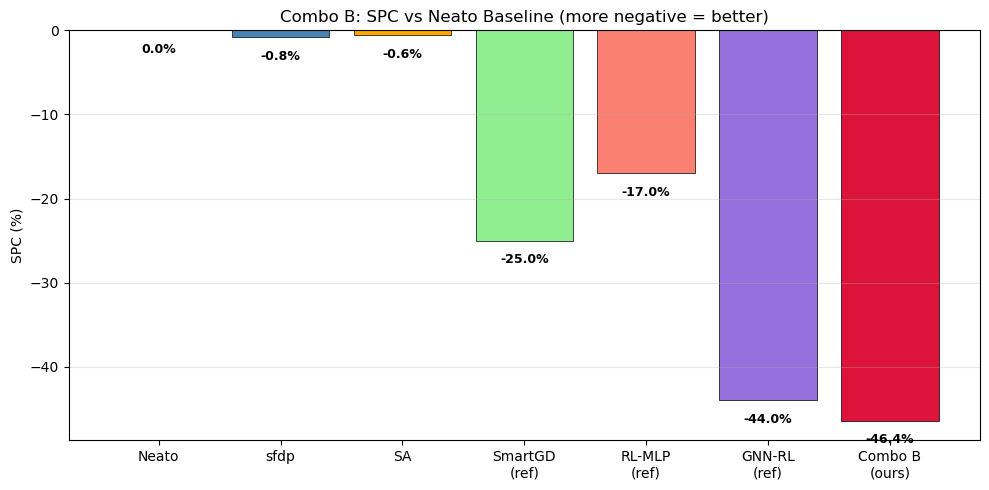

In [22]:
# ── SPC computation for each method ──────────────────────────────────────

def compute_spc_for_method(full_results, method_key):
    """SPC = 100% * mean[(Di - Gi) / max(Di, Gi)]  where Di=method, Gi=neato."""
    vals = []
    for r in full_results:
        Di = r[method_key]
        Gi = r["neato_crossings"]
        denom = max(Di, Gi)
        if denom > 0:
            vals.append((Di - Gi) / denom)
        else:
            vals.append(0.0)
    return 100.0 * np.mean(vals)


spc_ours = compute_spc_for_method(full_results, "best_crossings")
spc_sfdp = compute_spc_for_method(full_results, "sfdp_crossings")
spc_sa   = compute_spc_for_method(full_results, "sa_crossings")

# Teacher reference values (from assignment results table)
teacher_ref = {
    "neato":   0.0,
    "sfdp":    None,  # computed above
    "SmartGD": -25.0,
    "SA":      None,  # computed above
    "RL-MLP":  -17.0,
    "GNN-RL":  -44.0,
}

print("=" * 80)
print("SPC RESULTS (vs Neato baseline)")
print("=" * 80)
print(f"  {'Method':<25} {'SPC (%)':>10}")
print(f"  {'-'*25} {'-'*10}")
print(f"  {'Neato (baseline)':<25} {'0.00':>10}")
print(f"  {'sfdp':<25} {spc_sfdp:>10.2f}")
print(f"  {'SA (ours)':<25} {spc_sa:>10.2f}")
print(f"  {'SmartGD (teacher ref)':<25} {'-25.00':>10}")
print(f"  {'RL-MLP (teacher ref)':<25} {'-17.00':>10}")
print(f"  {'GNN-RL (teacher ref)':<25} {'-44.00':>10}")
print(f"  {'Combo B (ours)':<25} {spc_ours:>10.2f}")
print(f"  {'-'*25} {'-'*10}")

# ── Per-graph statistics ──
our_crossings  = [r["best_crossings"] for r in full_results]
neato_crossings = [r["neato_crossings"] for r in full_results]
print(f"\n  Total test graphs: {len(full_results)}")
print(f"  Our avg crossings:   {np.mean(our_crossings):.1f}")
print(f"  Neato avg crossings: {np.mean(neato_crossings):.1f}")
print(f"  Graphs where ours < neato: {sum(1 for o, n in zip(our_crossings, neato_crossings) if o < n)}/{len(full_results)}")
print(f"  Graphs with 0 crossings:   {sum(1 for o in our_crossings if o == 0)}/{len(full_results)}")

# ── Package .coord files into tar.gz ──
tar_path = os.path.join(OUTPUT_DIR, "combo_b_submission.tar.gz")
with tarfile.open(tar_path, "w:gz") as tar:
    for r in full_results:
        coord_file = os.path.join(COORD_DIR, f"{r['graph']}.coord")
        if os.path.exists(coord_file):
            tar.add(coord_file, arcname=f"{r['graph']}.coord")

print(f"\n  Submission tar.gz: {tar_path}")
print(f"  Files in archive: {len(full_results)}")

# ── Bar chart comparison ──
fig, ax = plt.subplots(figsize=(10, 5))
methods = ["Neato", "sfdp", "SA", "SmartGD\n(ref)", "RL-MLP\n(ref)", "GNN-RL\n(ref)", "Combo B\n(ours)"]
spcs = [0.0, spc_sfdp, spc_sa, -25.0, -17.0, -44.0, spc_ours]
colors = ["gray", "steelblue", "orange", "lightgreen", "salmon", "mediumpurple", "crimson"]
bars = ax.bar(methods, spcs, color=colors, edgecolor="black", linewidth=0.5)
ax.axhline(y=0, color="black", linewidth=0.5)
ax.set_ylabel("SPC (%)")
ax.set_title("Combo B: SPC vs Neato Baseline (more negative = better)")
ax.grid(axis="y", alpha=0.3)
for bar, val in zip(bars, spcs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 1.5,
            f"{val:.1f}%", ha="center", va="top", fontsize=9, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "combo_b_spc_comparison.png"), dpi=150)
print(f"  Chart saved to {OUTPUT_DIR}/combo_b_spc_comparison.png")
plt.show()

In [24]:
%run verify_combo_bv4.py

  VERIFYING: Combo B
Test graphs in Rome dataset (10000-10100): 99

1. Coord files: 99 / 99
   ALL test graphs have .coord files

2. Checking overlaps and format...
   NO overlapping nodes found
   All .coord files have correct format

3. Checking tar.gz...
   results_combo_b_v4/combo_b_submission.tar.gz: 99 files in archive
   Archive matches .coord file count

  Combo B: ALL CHECKS PASSED
